In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys

import numpy as np
import nibabel as nb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from tqdm.auto import tqdm
    
sys.path.insert(1, "../../")
import precision_mapping as pm
import xmath_tools as xmt
import CAP_tools

sys.path.insert(1, "../../network_control")
import surface_mapping as sfm

# Create Cifti List 

In [2]:
cifti_dir = "/home/cole/_research/data/HCP_7T_ciftis"
cifti_dir = "/Users/cole/_tmp/"

cifti_paths = sorted(glob.glob(f"{cifti_dir}/*REST*.dtseries.nii"))
subjects = [path.split("--", maxsplit=3)[1] for path in cifti_paths]

In [3]:
for path in tqdm(cifti_paths):
    path
    # cifti = nb.load(path)
    
    # data = cifti.get_fdata(caching="unchanged")

  0%|          | 0/177 [00:00<?, ?it/s]

# Compare 2 ciftis vFC

In [4]:
cifti = nb.load(cifti_paths[0])
cifti2 = nb.load(cifti_paths[1])

data1 = cifti.get_fdata(caching="unchanged").astype("float16")
data2 = cifti2.get_fdata(caching="unchanged").astype("float16")

In [18]:
cortex_data1 = pm.na.get_cortex_data(data1, cifti)
pair_data = np.stack((cortex_data1[:600], cortex_data1[600:1200]), axis=2)
pair_data = np.stack((cortex_data1[:600], cortex_data1[-600:]), axis=2)
pair_data = np.stack((cortex_data1[:300], cortex_data1[900:1200]), axis=2)
pair_data = np.stack((cortex_data1[:100], cortex_data1[1100:1200]), axis=2)
# pair_data = np.stack((data1[:600], data1[600:1200]), axis=2)
# pair_data = np.stack((data1, data2), axis=2).astype("float16")

In [19]:
r = xmt.PairCorrelator.run(pair_data, axis=None, threshold=None, backend="torch", device="cpu")
print(r, r ** 2)

tensor(0.)
tensor(0.)


PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

0.21722000000000002 0.04718452840000001


In [14]:
r_axis = xmt.pair_correlation(pair_data, axis=1, threshold=None, block_size=2000, backend="torch", device="cpu")

PairCorrelatorAxis Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

# TODO:
[] compare stability of vFC over time

# Example of Paired vFC correlation

In [15]:
def percent_clip(arr, lower=None, upper=None):
    v = arr[~np.isnan(arr)]
    return np.clip(arr, np.percentile(v, lower or 0), np.percentile(v, upper or 100))

def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = percent_clip(values, *pclip)
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

In [16]:
r_axis_cortex = pm.na.get_cortex_data(r_axis.reshape(1, -1), cifti)

Text(0.5, 1.0, 'Correlation between Two Participants FC')

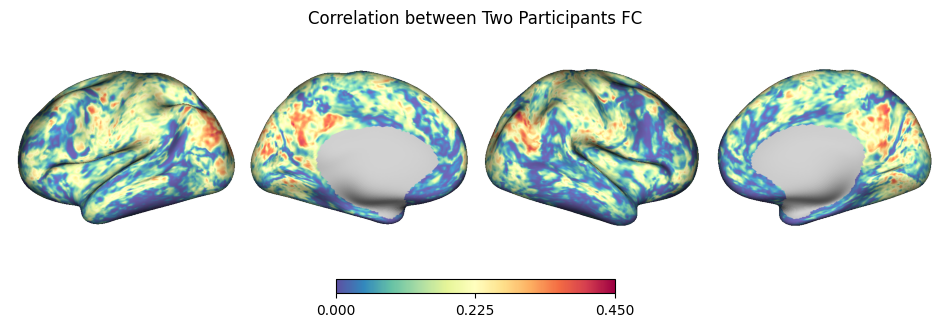

In [17]:
ax, _ = vertex_plot(r_axis_cortex[0] ** 2, cifti, cmap=plt.cm.Spectral_r, pclip=(0, 100))
ax.set_title("Correlation between Two Participants FC")

## Group Level Comparisons

In [54]:
EC_paths = sorted(glob.glob(f"{cifti_dir}/*sher*.dtseries.nii"))
EC_subjects = [path.split("--")[1] for path in EC_paths]
n_EC = len(EC_subjects)

In [60]:
combo_pairs = [(i, j) for i in range(n_EC) for j in range(n_EC) if i != j]
len(combo_pairs)

992

In [93]:
import gc
gc.collect()

1234

In [95]:
import pandas as pd

In [128]:
hcp_behav_df_path = "/Users/cole/Downloads/RESTRICTED_HCP_behavioral_data.csv"

hcp_behav_df = pd.read_csv(hcp_behav_df_path)
hcp_behav_df.columns = [col.lower() for col in hcp_behav_df.columns]
hcp_behav_df["subject"] = hcp_behav_df["subject"].astype(str)
hcp_behav_df = hcp_behav_df.loc[hcp_behav_df["subject"].isin(subjects)]

In [139]:
subject_pair_list = np.array([(s1, s2) for i, s1 in enumerate(subjects) for s2 in subjects[:i] if s1 != s2])

related_pairs = []
for i, g in hcp_behav_df.groupby("family_id"):
    subjs = g["subject"].values
    if len(subjs) < 2:
        continue
    add_pairs = sorted([(s1, s2) for i, s1 in enumerate(subjs) for s2 in subjs[:i] if s1 != s2])
    related_pairs += add_pairs
np.save("scratch/HCP_related_pairs.npy", related_pairs)

In [102]:
len(subject_pair_list)

15576

In [ ]:
subject_pair_list = np.array([(s1, s2) for i, s1 in enumerate(subjects) for s2 in subjects[:i] if s1 != s2])
subject_pair_id_list = np.array([(s1, s2) for s1, _ in enumerate(subjects) for s2, _ in enumerate(subjects[:s1]) if s1 != s2])
subject_pair_dfs = [hcp_sbr_df[hcp_sbr_df["subject"].isin(pair)] for pair in subject_pair_list]
twin_labels = np.array(["Unrelated" if len(df["family_id"].unique()) == 2 else df["zygositysr"].iloc[0] for df in subject_pair_dfs])

In [91]:
overwrite = False

for i, path_i in enumerate(tqdm(EC_paths)):
    cifti_i = nb.load(path_i)
    cortex_data_j = pm.na.get_cortex_data(cifti_i.get_fdata(caching="unchanged"), cifti_i)
    for j, path_j in enumerate(EC_paths):
        if path_j == path_i:
            continue
        pass
        subj_i, subj_j = EC_subjects[i], EC_subjects[j]
        save_path = f"scratch/vFC_corr_results/{subj_i}-{subj_j}_vFC_corr.npy"
        
        if os.path.exists(save_path) and not overwrite:
            continue
        
        cifti_j = nb.load(path_j)
        cortex_data_j = pm.na.get_cortex_data(cifti_j.get_fdata(caching="unchanged"), cifti_j)
        pair_data_ij = np.stack((data_i, data_j), axis=2)

        r_axis = xmt.pair_correlation(pair_data_ij, axis=1, leave=False, threshold=None,
                                      block_size=2000, backend="torch", device="mps")
        np.save(save_path, r_axis)
        break
    gc.collect()
    break

  0%|          | 0/32 [00:00<?, ?it/s]

PairCorrelatorAxis Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [88]:
np.save(save_path, r_axis)

In [89]:
ls scratch/vFC_corr_results/

ec_00_0001-ec_00_0018_vFC_corr.npy
